# Master Project Python & R - Association between Muscle Strength and Functional Performance in Patients with ILD

## Python - Data preparation en exploratory analysis - Inès Vincent

#### This notebook contains the code for data preparation and exploratory analysis of the dataset. 

In [25]:
# Install the required packages before running this notebook.
# Remove the comment symbol (#) before each line to install the packages.
#%pip install openpyxl
#%pip install seaborn
#%pip install pandas
#%pip install matplotlib
#%pip install seaborn

#install packages to put this notebook in a .html format
#%pip install nbconvert

## I- Import and clean the data

#### 1. Import necessary libraries, and load the dataset


In [26]:
#import necessary libraries.
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
file_path = "data/raw/frapid_base.xlsx"

if os.path.exists(file_path):
    frapid_data_raw = pd.read_excel(file_path)
    print("Shape:", frapid_data_raw.shape)
    print("Columns:", frapid_data_raw.columns)
else:
    print(f"File not found: {file_path}")

frapid_data_raw.head()


Shape: (47, 57)
Columns: Index(['patient_id', 'visit_date', 'birth_year', 'age', 'gender', 'weight',
       'height', 'BMI', 'smoking', 'pack_per_year', 'family_history', 'COPD',
       'resection', 'PH', 'cortico', 'cancer', 'M0_dyspnea', 'M0_LTOT',
       'M0_walkingO2', 'M0_PFT_date', 'M0_FVCL)', 'M0_FVC(%)', 'M0_DLCO(%)',
       'ILD_GAP', 'charlson_index', 'SARC_F', 'SARC_F_patho', 'calf(cm)',
       'SARC_Calf', 'SARC_Calf_patho', 'Ishii', 'Ishii_patho', 'walk_time_4m',
       'time_5_raise_chair', 'handgrip_strength', 'body_fat', 'lean_body_mass',
       'muscle_mass', 'resistance', 'ASM_R', 'ASM(0,52)', 'muscle_index(m2)',
       'sarcopenia', 'severe_sarcopenia', 'Fried', 'frail', 'pre_frail',
       'frailty', 'FRAIL', 'FRAIL_patho', 'EFC', 'EFC_patho', 'GFST',
       'GFST_patho', 'HAD', 'HAD_patho', 'KBILD'],
      dtype='str')


,patient_id,visit_date,birth_year,age,gender,weight,height,BMI,smoking,pack_per_year,...,frailty,FRAIL,FRAIL_patho,EFC,EFC_patho,GFST,GFST_patho,HAD,HAD_patho,KBILD
0,1,2025-02-04,1946,79,M,60.0,1.70,20.761246,ExF,10.0,...,préfragile,2,0,2.0,0.0,2,0,0,0,NaN
1,2,2025-02-11,1953,72,F,95.0,1.60,37.109375,NF,NaN,...,préfragile,3,1,4.0,0.0,4,0,15,1,39.0
2,3,2025-02-11,1942,83,M,54.0,1.58,21.631149,ExF,35.0,...,préfragile,0,0,2.0,0.0,0,0,4,0,105.0
3,4,2025-02-11,1949,76,F,175.0,1.70,60.553633,ExF,40.0,...,fragile,4,1,6.0,1.0,3,0,11,1,77.0
4,5,2025-02-13,1948,77,M,77.0,1.68,27.281746,ExF,60.0,...,préfragile,1,0,4.0,0.0,0,0,10,0,74.0


#### 2. Create a working copy of the data (so you don't modify the raw data and you can keep it safe in case of problems). 

In [28]:
# Database copy to work on, to avoid modifying the original data.
frapid_data = frapid_data_raw.copy()
frapid_data.head()

,patient_id,visit_date,birth_year,age,gender,weight,height,BMI,smoking,pack_per_year,...,frailty,FRAIL,FRAIL_patho,EFC,EFC_patho,GFST,GFST_patho,HAD,HAD_patho,KBILD
0,1,2025-02-04,1946,79,M,60.0,1.70,20.761246,ExF,10.0,...,préfragile,2,0,2.0,0.0,2,0,0,0,NaN
1,2,2025-02-11,1953,72,F,95.0,1.60,37.109375,NF,NaN,...,préfragile,3,1,4.0,0.0,4,0,15,1,39.0
2,3,2025-02-11,1942,83,M,54.0,1.58,21.631149,ExF,35.0,...,préfragile,0,0,2.0,0.0,0,0,4,0,105.0
3,4,2025-02-11,1949,76,F,175.0,1.70,60.553633,ExF,40.0,...,fragile,4,1,6.0,1.0,3,0,11,1,77.0
4,5,2025-02-13,1948,77,M,77.0,1.68,27.281746,ExF,60.0,...,préfragile,1,0,4.0,0.0,0,0,10,0,74.0


Next, we keep only the columns that are useful for our analysis and convert the relevant columns to numeric values. This will help us in the subsequent analysis steps. We will also check for missing values and handle them appropriately.

In [29]:
# Keep only useful columns (still on the working copy)
frapid_data = frapid_data[["patient_id", "age", "gender", "handgrip_strength", "walk_time_4m", "time_5_raise_chair"]].copy()
frapid_data.head()
# Convert to numeric values
frapid_data["patient_id"] = pd.to_numeric(frapid_data["patient_id"], errors="coerce")
frapid_data["age"] = pd.to_numeric(frapid_data["age"], errors="coerce")
frapid_data["handgrip_strength"] = pd.to_numeric(frapid_data["handgrip_strength"], errors="coerce")
frapid_data["walk_time_4m"] = pd.to_numeric(frapid_data["walk_time_4m"], errors="coerce")
frapid_data["time_5_raise_chair"] = pd.to_numeric(frapid_data["time_5_raise_chair"], errors="coerce")

print("Missing values per column:")
print(frapid_data.isna().sum())

frapid_data.head()

Missing values per column:
patient_id            0
age                   0
gender                0
handgrip_strength     0
walk_time_4m          0
time_5_raise_chair    1
dtype: int64


,patient_id,age,gender,handgrip_strength,walk_time_4m,time_5_raise_chair
0,1,79,M,35,2.7,9.0
1,2,72,F,22,4.0,11.0
2,3,83,M,24,3.0,8.0
3,4,76,F,22,14.0,NaN
4,5,77,M,26,4.0,13.0


In [30]:
# Suppress rows with missing values
frapid_data_clean = frapid_data.dropna()

print("Missing values per column:")
print(frapid_data_clean.isna().sum())
print("Number of patients after cleaning:", len(frapid_data_clean))

Missing values per column:
patient_id            0
age                   0
gender                0
handgrip_strength     0
walk_time_4m          0
time_5_raise_chair    0
dtype: int64
Number of patients after cleaning: 46


## II - Create a variable for walking speed

We will create a new variable for walking speed in meters per second (m/s) by dividing the distance walked (4 meters) by the time taken to walk that distance (walk_time_4m). This will allow us to analyze walking speed as a continuous variable in our analysis.

In [31]:
# Create a variable for walking speed in m/s in the cleaned dataset
WALK_DISTANCE_METERS = 4

frapid_data_clean["walking_speed_mps"] = ( WALK_DISTANCE_METERS / frapid_data_clean["walk_time_4m"]).round(2)

# Check the calculation
frapid_data_clean[["walk_time_4m", "walking_speed_mps"]].head(10)

,walk_time_4m,walking_speed_mps
0,2.7,1.48
1,4.0,1.00
2,3.0,1.33
4,4.0,1.00
5,2.7,1.48
6,2.7,1.48
7,9.0,0.44
8,2.5,1.60
9,4.0,1.00
10,2.2,1.82


In [32]:
# Save cleaned dataset with all useful variables
frapid_data_clean.to_csv("data/clean/frapid_data_clean.csv", index=False)
frapid_data_clean.to_csv("results/tables/frapid_data_clean.csv", index=False)

print("Clean dataset saved in data/clean/frapid_data_clean.csv and results/tables/frapid_data_clean.csv")

frapid_data_clean.head()

Clean dataset saved in data/clean/frapid_data_clean.csv and results/tables/frapid_data_clean.csv


,patient_id,age,gender,handgrip_strength,walk_time_4m,time_5_raise_chair,walking_speed_mps
0,1,79,M,35,2.7,9.0,1.48
1,2,72,F,22,4.0,11.0,1.00
2,3,83,M,24,3.0,8.0,1.33
4,5,77,M,26,4.0,13.0,1.00
5,6,79,M,20,2.7,15.0,1.48


## III - Exploratory data analysis

In this section, we perform an exploratory data analysis to describe the study population and to explore the relationships between handgrip strength, walking speed, and functional performance before conducting formal statistical tests. We will use descriptive statistics and visualizations to summarize the data and identify any patterns or trends that may be present. 

In [33]:
# Descriptive statistics
descriptive_stats = frapid_data_clean[
    ["age", "handgrip_strength", "walk_time_4m", "walking_speed_mps", "time_5_raise_chair"]
].describe().round(2)

descriptive_stats.to_csv("results/tables/descriptive_statistics.csv")
print("Descriptive statistics saved in results/tables/descriptive_statistics.csv")

descriptive_stats

Descriptive statistics saved in results/tables/descriptive_statistics.csv


,age,handgrip_strength,walk_time_4m,walking_speed_mps,time_5_raise_chair
count,46.00,46.00,46.00,46.00,46.00
mean,76.24,29.50,3.56,1.33,13.54
std,5.98,9.28,1.66,0.52,5.52
min,66.00,7.00,1.50,0.44,5.00
25%,71.00,24.00,2.50,0.87,10.25
50%,76.50,30.00,3.00,1.33,12.00
75%,80.00,36.00,4.63,1.60,15.00
max,89.00,50.00,9.00,2.67,36.00


In [34]:
# Describe the gender distribution in the cleaned dataset
print("Counts:")
print(frapid_data_clean["gender"].value_counts())

print("\nPercentages (%):")
print((frapid_data_clean["gender"].value_counts(normalize=True) * 100).round(1))

Counts:
gender
M    36
F    10
Name: count, dtype: int64

Percentages (%):
gender
M    78.3
F    21.7
Name: proportion, dtype: float64


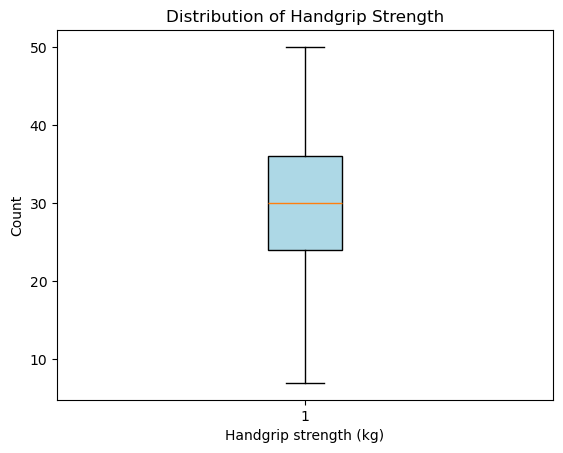

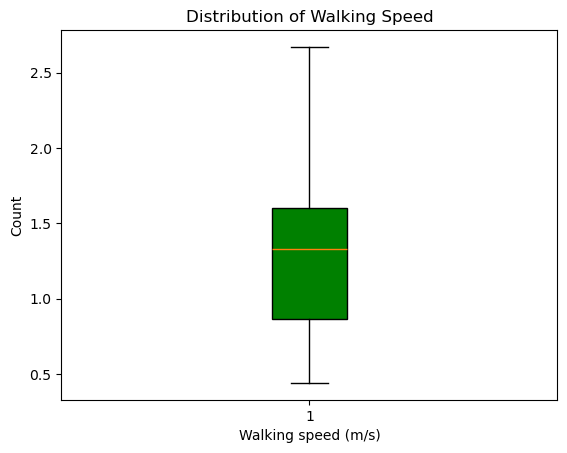

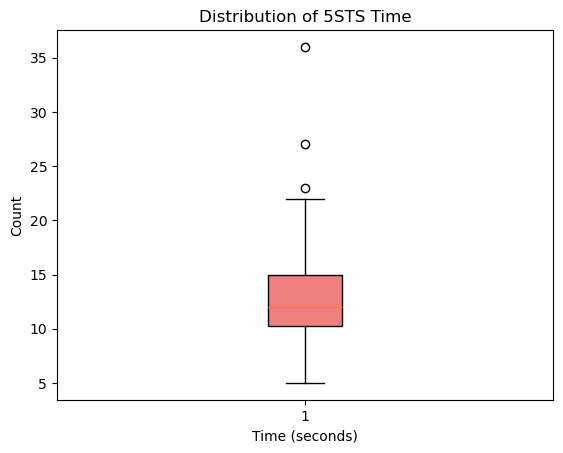

In [35]:
# Visualize the distribution of the main variables
plt.figure()
plt.boxplot(frapid_data_clean["handgrip_strength"], patch_artist=True, boxprops=dict(facecolor="lightblue", edgecolor="black", linewidth=1))
plt.title("Distribution of Handgrip Strength")
plt.xlabel("Handgrip strength (kg)")
plt.ylabel("Count")
plt.savefig("results/figures/handgrip_strength_distribution.png", dpi=300)
plt.show()

plt.figure()
plt.boxplot(frapid_data_clean["walking_speed_mps"], patch_artist=True, boxprops=dict(facecolor="green", edgecolor="black", linewidth=1))
plt.title("Distribution of Walking Speed")
plt.xlabel("Walking speed (m/s)")
plt.ylabel("Count")
plt.savefig("results/figures/walking_speed_distribution.png", dpi=300)
plt.show()

plt.figure()
plt.boxplot(frapid_data_clean["time_5_raise_chair"], patch_artist=True, boxprops=dict(facecolor="lightcoral", edgecolor="black", linewidth=1))
plt.title("Distribution of 5STS Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.savefig("results/figures/5sts_time_distribution.png", dpi=300)
plt.show()

These box plots illustrate the distribution of the functional variables within the sample. A box plot provides a visual summary of the central tendency, variability, and potential outliers in the data. The median is represented by the line inside the box, while the edges of the box represent the interquartile range (IQR). The whiskers extend to the minimum and maximum values, and any point outside this range is considered an outlier and is plotted individually. This visualization helps us understand the overall distribution of the variables within our study population.

It shows that grip strength has a median of approximately 30 kg, with considerable variability but no marked outliers. Walking speed is centered around 1.3 m/s, with moderate dispersion reflecting heterogeneous functional levels. In contrast, the time required to stand up and sit down five times on a chair (5STS) is more asymmetrical, with several high values, suggesting a non-normal distribution and the presence of patients with impaired performance.


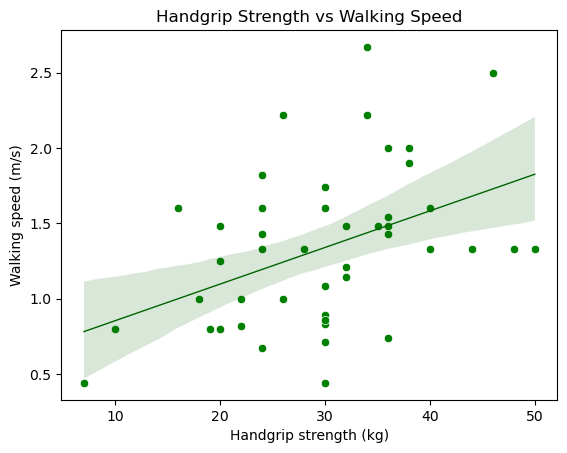

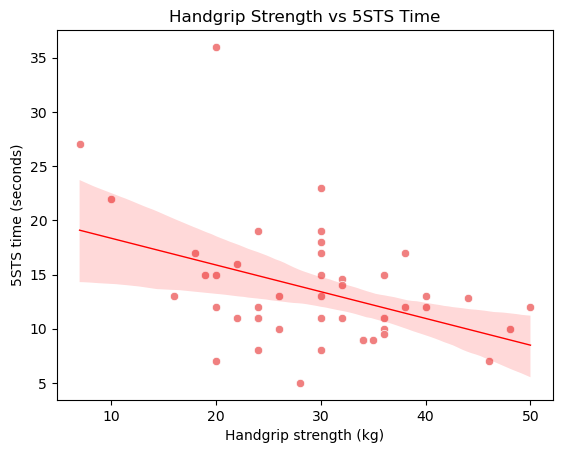

In [36]:
# Visualize the relationship between handgrip strength and walking speed, and handgrip strength and 5STS time
# Primary analysis: handgrip vs walking speed
plt.figure()
sns.scatterplot(data=frapid_data_clean, x="handgrip_strength", y="walking_speed_mps", color="green")
sns.regplot(data=frapid_data_clean, x="handgrip_strength", y="walking_speed_mps", scatter=False, color="darkgreen", line_kws={"linewidth": 1})
plt.title("Handgrip Strength vs Walking Speed")
plt.xlabel("Handgrip strength (kg)")
plt.ylabel("Walking speed (m/s)")
plt.savefig("results/figures/handgrip_vs_walking_speed_scatterplot.png", dpi=300)
plt.show()


# Secondary analysis: handgrip vs 5STS
plt.figure()
sns.scatterplot(data=frapid_data_clean, x="handgrip_strength", y="time_5_raise_chair", color="lightcoral")
sns.regplot(data=frapid_data_clean, x="handgrip_strength", y="time_5_raise_chair", scatter=False, color="red", line_kws={"linewidth": 1})
plt.title("Handgrip Strength vs 5STS Time")
plt.xlabel("Handgrip strength (kg)")
plt.ylabel("5STS time (seconds)")
plt.savefig("results/figures/handgrip_vs_5sts_scatterplot.png", dpi=300)
plt.show()

This graph shows the relationship between handgrip strength and walking speed, and between handgrip strength and 5STS time. Each point represents an individual patient, with handgrip strength on the x-axis and walking speed and 5STS time on the y-axis. The plot allows us to visually assess whether there is a positive correlation between these variables. The presence of a trend line can further illustrate the strength and direction of this relationship.

These scatter plots suggest a positive correlation between handgrip strength and walking speed, as well as a negative correlation between handgrip strength and 5STS time. Patients with higher handgrip strength tend to have faster walking speeds and shorter times to complete the 5STS test, indicating better functional performance. However, the presence of some outliers and variability in the data suggests that other factors may also influence these relationships, and further statistical analysis is needed to confirm these observations.

To confirm these observations, statistical analyses will be performed using R, allowing for the calculation of correlation coefficients and associated p-values to formally assess the strength and significance of these relationships.